# Redes Neuronales Convolucionales para detección de neumonía

### Diana Gómez

## 0. Librerías a importar

- `medmnist`: donde están almacenados los datos - las imágenes médicas clasificadas en nemonía sí o no
- `torch`: funciones para el desarrollo del modelo
- `matplotlib`: visualización de datos y gráficas de rendimiento del modelo


In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00


In [2]:
from medmnist import PneumoniaMNIST, INFO
from sklearn.metrics import confusion_matrix, recall_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import random

## 1. Cargamos los datos

Importamos y visualizamos los datos:

Estos vienen ya separados en conjunto de entrenamiento, validación y prueba: 80%, 10% y 10%.

Mantemeos esta división, realizando el entrenamiento con validación cruzada one round. Si bien otros tipos de validación son más robustos (validación cruzada), en este caso esta es la más apropiada debido a la gran cantidad de datos con la que debemos trabajar (5856 imágenes).
<br>

También cargamos las etiquetas del conjunto:
- 0 = sano
- 1 = neumonía

Los datos están balanceados.

In [3]:
# Descargamos el dataset
train_df = PneumoniaMNIST(split='train', download=True)
val_df = PneumoniaMNIST(split='val', download=True)
test_df = PneumoniaMNIST(split='test', download=True)

# Comprobamos que tenemos el numero de imagenes necesarias
print(f"Número de imágenes de entrenamiento: {len(train_df)}") # comprobamos que son 4.708
print(f"Tipo de objeto: {type(train_df[0][0])}")
print(f"Número de imágenes de validación: {len(val_df)}") # comprobamos que son 524
print(f"Número de imágenes de test: {len(test_df)}") # comprobamos que son 624

100%|██████████| 4.17M/4.17M [00:00<00:00, 4.47MB/s]

Número de imágenes de entrenamiento: 4708
Tipo de objeto: <class 'PIL.Image.Image'>
Número de imágenes de validación: 524
Número de imágenes de test: 624


In [4]:
### Determinamos las etiquetas

data_flag = 'pneumoniamnist'
info = INFO[data_flag]

print("Diccionario de etiquetas oficial:")
print(info['label'])

Diccionario de etiquetas oficial:
{'0': 'normal', '1': 'pneumonia'}


## 2. Visualización de los datos cargados

Visualizamos una imagen de cada data set para saber con qué estamos trabajando
Usamos una semilla aleatoria para que la selección sea reproducible.

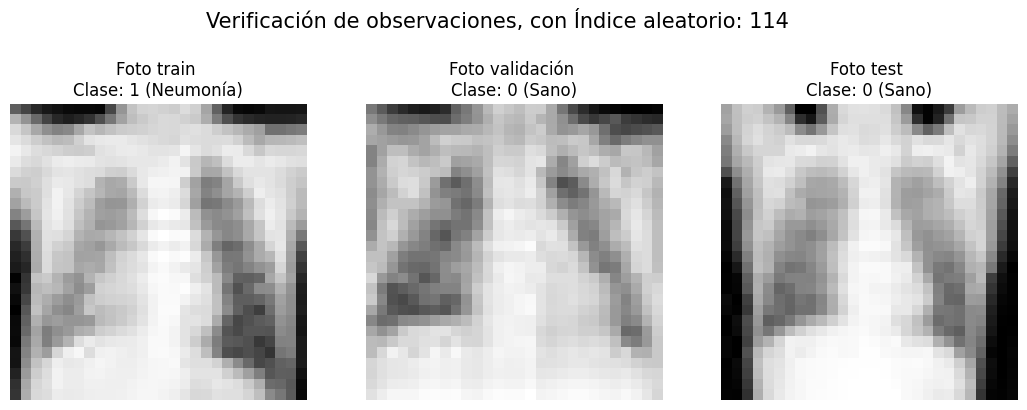

In [5]:
###  Las imagenes que vamos a sacar por pantalla

# Semilla reproducible
random.seed(42)

# Usamos len(val_df) para asegurar que el indice 's' existe en los tres datasets
s = random.randint(0, len(val_df) - 1) # el de validation es el mas pequenyo
train_img, train_label = train_df[s]
val_img, val_label = val_df[s]
test_img, test_label = test_df[s]

## Funcion para convertir la etiqueta en su valor (0=Sano, 1=Neumonia)
def func_clase(etiqueta):
    if etiqueta[0] == 0:
        return "Sano"
    else:
        return "Neumonía"

## Grafica
plt.figure(figsize=(13, 5))

# Imagen de Entrenamiento
plt.subplot(1, 3, 1)
plt.imshow(train_img, cmap='gray')
plt.title(f"Foto train \nClase: {train_label[0]} ({func_clase(train_label)})")
plt.axis('off')

# Imagen de Validacion
plt.subplot(1, 3, 2)
plt.imshow(val_img, cmap='gray')
plt.title(f"Foto validación \nClase: {val_label[0]} ({func_clase(val_label)})")
plt.axis('off')

# Imagen de Test
plt.subplot(1, 3, 3)
plt.imshow(test_img, cmap='gray')
plt.title(f"Foto test \nClase: {test_label[0]} ({func_clase(test_label)})")
plt.axis('off')

plt.suptitle(f"Verificación de observaciones, con Índice aleatorio: {s}", fontsize=15)
plt.show()

## Diseño de la red convolucional (CNN)

In [7]:
### Preparamos el data set

# Los numeros deben estar en un rango pequenyo para que la red aprenda
transformacion = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = PneumoniaMNIST(split='train', transform=transformacion, download=True)
val_dataset = PneumoniaMNIST(split='val', transform=transformacion, download=True)
test_dataset = PneumoniaMNIST(split='test', transform=transformacion, download=True)

clases = ('Sano', 'Neumonía')

In [8]:
### CNN en si:

class NeumoniaCNN(nn.Module):

    def __init__(self):
        super(NeumoniaCNN, self).__init__()

        # capa de convolucion primera
        self.conv1 = nn.Conv2d(1,8,kernel_size=3,padding=1) # filtro 3x3, padding para matener el tamanyo de la imagen
                                                            # 1 = tenemos un unico canal (imagen en blanco y negro)
                                                            # 8 = crea 8 mapas de caracteristicas distintos de la imagen

        # capa de agrupacion (pool)
        self.pool = nn.MaxPool2d(2,2) # tamanyo 2x2 y paso 2, reduce la imagen a 14x14

        # capa de convolucion segunda = caracteristicas mas abstractas
        self.conv2 = nn.Conv2d(8,16,kernel_size=3,padding=1) # filtro 3x3, padding para matener el tamanyo de la imgagen
                                                             # 8 = de la capa anterior tenemos 8 canales
                                                             # 16 = crea 16 mapas de caracteristicas distintos de la imagen
        # capa fully connected = clasificacion
        self.fullycon1 = nn.Linear(16 * 7 * 7, 64)
        self.fullycon2 = nn.Linear(64,2) # porque solo hay 2 clases


    def forward(self, x):
        # primer bloque: pool(reLu(convol1))
        x = self.pool(F.relu(self.conv1(x)))

        # segundo bloque: pool(reLu(convol2))
        x = self.pool(F.relu(self.conv2(x)))

        # hay que aplanar la imagen para la capa lineal
        x = x.view(-1, 16 * 7 * 7)

        # realizar la clasificacion = usar las capas fully connected
        x = F.relu(self.fullycon1(x))
        x = self.fullycon2(x)
        return x


### CNN desarrollada
red = NeumoniaCNN()
print(red)

NeumoniaCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fullycon1): Linear(in_features=784, out_features=64, bias=True)
  (fullycon2): Linear(in_features=64, out_features=2, bias=True)
)


## Regla de ajuste de pesos

En cuanto a la regla de ajuste de pesos, existen diversas reglas aplicables a las CNN. Para esta red, hemos empleado el algoritmo de optimización de Adam (Adaptative moment estimation). Es un algoritmo de optimización de descenso de gradiente ampliamente utilizado en aprendizaje profundo.

In [9]:
optimizer = optim.Adam(red.parameters(), lr=0.001)

## Función de pérdida

La función de pérdida empleada es la entropía cruzada, puesto que se
trata de una red de clasificación binaria.
Esta es una función de pérdida ampliamente utilizada en problemas de clasificación, que calcula la diferencia entre la probabilidad predicha y las etiquetas verdaderas.

In [11]:
criterion = nn.CrossEntropyLoss()

## Entrenamiento

In [ ]:
random.seed(21)

# Cargamos los datos de entrenamiento y validacion
train_batches = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
val_batches = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)

num_epochs = 17
for epoch in range(num_epochs): # probamos a ir entrenandola con desde 1 a 17 epochs, y vamos validando cada vez

    ###### FASE DE ENTRENAMIENTO
    red.train() # ponemos la red en modo entrenamiento
    func_loss = 0.0 # inicializamos el valor de la funcion de perdida

    # Batches = cada epoch la haremos en batches de 32
    for i, data in enumerate(train_batches, 0):

        # obtener las imagenes y las etiquetas del batch
        inputs, labels = data
        labels = labels.squeeze().long()

        # inicializamos a cero los gradientes para evitar errores
        optimizer.zero_grad()

        # clasificamos la imagen (forward pass)
        outputs = red(inputs)

        # comparamos la clasificacion con la realidad
        loss = criterion(outputs, labels)

        # calculamos cuanto se ha equivocado cada neurona (backpropagation)
        loss.backward()

        # ajustamos los pesos de la red con el algoritmo de Adam
        optimizer.step()

        # calculamos la funcion de perdida del entrenamiento
        func_loss += loss.item()

    ###### FASE DE VALIDACION
    red.eval() # ponemos la red en modo evaluacion (no aprende en esta fase)
    val_func_loss = 0.0

    # desactivamos el calculo de gradientes para ir mas rapido y no gastar memoria
    with torch.no_grad():
        for data in val_batches:
            # obtener imagenes y etiquetas de validacion
            inputs, labels = data
            labels = labels.squeeze().long()

            # clasificar sin ajustar pesos
            outputs = red(inputs)

            # calcular la perdida en validacion para comparar
            loss = criterion(outputs, labels)
            val_func_loss += loss.item()

    # calculamos el error medio de entrenamiento y de validacion
    train_error = func_loss / len(train_batches)
    val_error = val_func_loss / len(val_batches)

    # al finalizar la epoch, imprimimos ambos errores para ver si hay sobreajuste
    print(f'Epoch {epoch + 1} - Train Loss: {train_error:.4f} | Val Loss: {val_error:.4f}')

print('Entrenamiento y validación de la CNN finalizados')

Epoch 1 - Train Loss: 0.0648 | Val Loss: 0.0925
Epoch 2 - Train Loss: 0.0573 | Val Loss: 0.0828
Epoch 3 - Train Loss: 0.0580 | Val Loss: 0.0982
Epoch 4 - Train Loss: 0.0545 | Val Loss: 0.0804
Epoch 5 - Train Loss: 0.0562 | Val Loss: 0.0816
Epoch 6 - Train Loss: 0.0537 | Val Loss: 0.0916
Epoch 7 - Train Loss: 0.0456 | Val Loss: 0.0854
Epoch 8 - Train Loss: 0.0386 | Val Loss: 0.0846
Epoch 9 - Train Loss: 0.0426 | Val Loss: 0.0893
Epoch 10 - Train Loss: 0.0367 | Val Loss: 0.1087
Epoch 11 - Train Loss: 0.0358 | Val Loss: 0.1159
Epoch 12 - Train Loss: 0.0338 | Val Loss: 0.0931
Epoch 13 - Train Loss: 0.0312 | Val Loss: 0.1001
Epoch 14 - Train Loss: 0.0339 | Val Loss: 0.1157
Epoch 15 - Train Loss: 0.0279 | Val Loss: 0.0871
Epoch 16 - Train Loss: 0.0249 | Val Loss: 0.1185
Epoch 17 - Train Loss: 0.0255 | Val Loss: 0.1057
Entrenamiento y validación de la CNN finalizados


Visualizamos graficamente el **error de entrenamiento** vs el **error de validación** para determinar el valor de epochs óptimo: aquel en que no hay sobreajuste de la red.

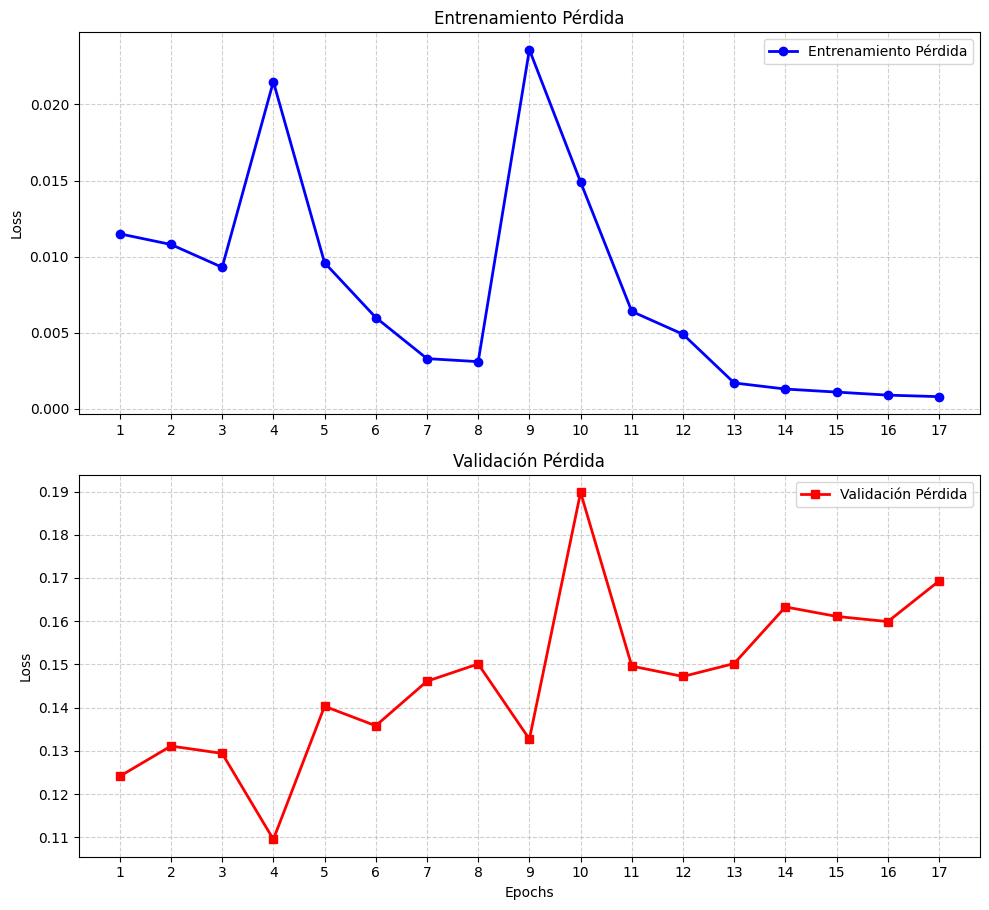

In [12]:
### Datos
epochs = list(range(1, 18))
train_loss = [0.0115, 0.0108, 0.0093, 0.0215, 0.0096, 0.0060, 0.0033, 0.0031, 0.0236, 0.0149, 0.0064, 0.0049, 0.0017, 0.0013, 0.0011, 0.0009, 0.0008]
val_loss = [0.1241, 0.1311, 0.1294, 0.1095, 0.1403, 0.1358, 0.1461, 0.1501, 0.1327, 0.1898, 0.1496, 0.1472, 0.1502, 0.1633, 0.1611, 0.1599, 0.1693]

## 2 graficas : entrenamiento y validacion
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

## Gr1: Entrenamiento
ax1.plot(epochs, train_loss, color='blue', marker='o', linewidth=2, label='Entrenamiento Pérdida')
ax1.set_title('Entrenamiento Pérdida', fontsize=12)
ax1.set_ylabel('Loss', fontsize=10)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

## Gr 2: Validacion
ax2.plot(epochs, val_loss, color='red', marker='s', linewidth=2, label='Validación Pérdida')
ax2.set_title('Validación Pérdida', fontsize=12)
ax2.set_xlabel('Epochs', fontsize=10)
ax2.set_ylabel('Loss', fontsize=10)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

## Espacio entre graficsa
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Podemos observar que el valor óptimo de epochs es **4**

Por tanto, reentrenamos la red con el valor óptimo de epochs

In [ ]:
#### Red final entrenada
random.seed(21)

num_epochs_opt = 4

for epoch in range(num_epochs_opt):

    ###### FASE DE ENTRENAMIENTO
    red.train() # ponemos la red en modo entrenamiento
    func_loss = 0.0

    # Batches = cada epoch la haremos en batches de 32
    for i, data in enumerate(train_batches, 0):

        # obtener las imágenes y las etiquetas del batch
        inputs, labels = data
        labels = labels.squeeze().long()

        # inicializamos a cero los gradientes para evitar errores
        optimizer.zero_grad()

        # clasificamos la imagen (forward pass)
        outputs = red(inputs)

        # comparamos la clasificacion con la realidad
        loss = criterion(outputs, labels)

        # calculamos cuánto se ha equivocado cada neurona (backpropagation)
        loss.backward()

        # ajustamos los pesos de la red con el algoritmo de Adam
        optimizer.step()

        # calculamos la funcion de perdida del entrenamiento
        func_loss += loss.item()

print('Entrenamiento con 4 epochs finalizada')

Entrenamiento con 4 epochs finalizada


## Test (Resultados)

Evaluamos el rendimiento de la red en el conjunto de test.
Para ello, obtendremos la **matriz de confusión**, así como la **sensibilidad**, pues en modelos médicos conviene no solo observar métricas como el accuracy, sino también la sensibilidad, para asegurarnos de que no dejamos a personas enfermas sin diagnosticar.

In [ ]:
# Datos de test, tambien en batches

test_batches = DataLoader(dataset=test_dataset, batch_size=32)

# Donde almacenaremos los resultados
predicciones_red = []
etiquetas_reales = []

red.eval() # ponemos la red en modo evaluacion (tampoco aprende asi)

# desactivamos el calculo de gradientes para el test
with torch.no_grad():
    for data in test_batches:

        # obtener imagenes y etiquetas de test
        inputs, labels = data
        labels = labels.squeeze().long()

        # la red clasifica cada imagen
        outputs = red(inputs)

        # sacamos la clase con mas probabilidad (0 o 1)
        _, predicted = torch.max(outputs, 1)

        # guardamos los resultados para comparar
        predicciones_red.extend(predicted.numpy())
        etiquetas_reales.extend(labels.numpy())


# Matriz de confusion
matriz_confusion = confusion_matrix(etiquetas_reales, predicciones_red)

# Sensibilidad
sensib = recall_score(etiquetas_reales, predicciones_red)

# Imprimimos los resultados finales para extraer conclusiones
print("\n Resultados del test set")
print(f"Sensibilidad de la red: {sensib:.4f}")
print("\nMatriz de Confusion de la red:")
print(matriz_confusion)


 Resultados del test set
Sensibilidad de la red: 0.9872

Matriz de Confusion de la red:
[[151  83]
 [  5 385]]
